# Two coupled $0$-$\pi$: $n_{\theta 1}\otimes n_{\theta 2}$

### 1. Define variable transform

$1->\phi_1, 2->\theta_1, 3->\chi_1, 4->\Sigma_1$

$5->\phi_2, 6->\theta_2, 7->\chi_2, 8->\Sigma_2$

$9->\varphi_9, 10->Ground$

In [1]:
import  os
num_cores = "1"
os.environ["OPENBLAS_NUM_THREADS"] = num_cores
os.environ["OMP_NUM_THREADS"] = num_cores
os.environ["MKL_NUM_THREADS"] = num_cores

In [2]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_two_qubit_gate as ut
ut.set_fig_font() ### Set various sizes in plotting

from qutip.qip.operations import rz, cz_gate

<img src="../image/2zp.png" alt="drawing" align="left" width="450"/>

### 2. Get circuit Hamiltonian

EC_theta = 0.092,   EC_phi = 1.142,   

EC = 1. / (0.5/EC_theta - 0.5/EC_phi) = 0.20012190476190478

Ec0=0.275  -->  g=0.0922

In [3]:
zp = scq.Circuit(ut.zp_yml, from_file=False)
zp.configure(transformation_matrix=np.linalg.inv(ut.transform_2zeropi))
zp.sym_hamiltonian()
print(zp.var_categories)
print(zp.cutoff_names)
zp.Ec0

<IPython.core.display.Latex object>

{'periodic': [2, 6], 'extended': [1, 3, 5, 7], 'free': [4, 8, 9], 'frozen': [], 'sigma': []}
['cutoff_n_2', 'cutoff_n_6', 'cutoff_ext_1', 'cutoff_ext_3', 'cutoff_ext_5', 'cutoff_ext_7']


1.0

### 3. Construct subsystem, calculate eigenvalues

In [4]:
trunc_dim = 10
system_hierarchy = [[1,2],  [5,6]]
subsystem_trunc_dims = [trunc_dim, trunc_dim]
zp.configure(system_hierarchy=system_hierarchy, subsystem_trunc_dims=subsystem_trunc_dims)

zp.cutoff_ext_1 = 100
zp.cutoff_n_2 = 30
zp.cutoff_ext_5 = 100
zp.cutoff_n_6 = 30

eval0, eket0 = zp.subsystems[0].eigensys(evals_count=trunc_dim)
eval1, eket1 = zp.subsystems[1].eigensys(evals_count=trunc_dim)
eval0 = eval0 - eval0[0]
eval1 = eval1 - eval1[0]
eket0 = ssp.csr_matrix([eket0[:,idx] for idx in range(trunc_dim)])
eket1 = ssp.csr_matrix([eket1[:,idx] for idx in range(trunc_dim)])

print(np.shape(eket1))
# zp.subsystems[0].n2_operator()
zp.sym_interaction((1,0))  # show coupling terms between subsystems 0 and 1
zp.sym_hamiltonian(subsystem_index=0)
zp.sym_hamiltonian(subsystem_index=1)
# print( zp.subsystems[0].ng2, '  ', zp.subsystems[1].ng6)
# print( zp.subsystems[0].external_flux_values(), '  ', zp.subsystems[1].external_flux_values())

(10, 6100)


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### 4. Sort bare system eigenvalues, get dressed index

In [5]:
eval_bare_1d = []
order_1d = []
for idx, val0 in enumerate(eval0):
    for jdx, val1 in enumerate(eval1):
        eval_bare_1d.append(val0 + val1)
        order_1d.append(str(idx) + str(jdx))
eval_bare_2d = np.reshape(eval_bare_1d, (trunc_dim, trunc_dim) )
order_2d = np.reshape(order_1d, (trunc_dim, trunc_dim) )

sort_idx = np.argsort(eval_bare_1d)
eval_bare_sort = np.sort(eval_bare_1d)
order_sort = [order_1d[i] for i in sort_idx]
print(order_sort[:100])
print(eval_bare_sort[:trunc_dim])

['00', '01', '10', '02', '03', '20', '30', '04', '11', '40', '05', '06', '21', '31', '50', '60', '12', '13', '07', '70', '08', '22', '32', '23', '33', '14', '80', '41', '09', '24', '34', '90', '15', '16', '51', '61', '42', '43', '17', '71', '25', '35', '26', '36', '52', '53', '62', '63', '18', '27', '37', '81', '44', '72', '73', '28', '38', '19', '91', '54', '64', '82', '83', '45', '46', '47', '29', '39', '74', '92', '93', '55', '65', '56', '66', '48', '84', '57', '67', '75', '76', '77', '58', '68', '49', '94', '85', '86', '78', '87', '59', '69', '95', '96', '88', '79', '97', '98', '89', '99']
[0.         2.4289437  2.5796729  3.40993052 3.41123859 3.44340002
 3.44403998 4.7202231  5.0086166  5.0258124 ]


### 5. Get total Hamiltonian in dressed basis

In [6]:
# get the representation of the n_b operator in the dressed eigenbasis of the composite system
n_theta1 = np.zeros((trunc_dim, trunc_dim),dtype=complex)
for idx, vec1 in enumerate(eket0):
    for jdx, vec2 in enumerate(eket0):
        n_theta1[idx,jdx] = (vec1 @ zp.subsystems[0].n2_operator() @ vec2.H).toarray()

n_theta2 = np.zeros((trunc_dim, trunc_dim),dtype=complex)
for idx, vec1 in enumerate(eket1):
    for jdx, vec2 in enumerate(eket1):
        n_theta2[idx,jdx] = (vec1 @ zp.subsystems[1].n6_operator() @ vec2.H).toarray()

Hint = qt.tensor(qt.Qobj(n_theta1) , qt.Qobj(n_theta2))

n2, n6 = symbols('n2 n6')
g = zp.sym_interaction((1,0), return_expr=True).coeff(n2*n6)
H_bare = (  qt.tensor(qt.Qobj(np.diag(eval0)),  qt.identity(trunc_dim))
          +  qt.tensor(qt.identity(trunc_dim),  qt.Qobj(np.diag(eval1))) )
Htot = g* Hint + H_bare
eval_tot, eket_tot = Htot.eigenstates()
eval_tot = eval_tot - eval_tot[0]

n_theta1_dress = qt.tensor(qt.Qobj(n_theta1), qt.identity(trunc_dim))
n_theta1_dress_mat = np.zeros((trunc_dim**2, trunc_dim**2), dtype=complex)
for idx, vec1 in enumerate(eket_tot):
    for jdx, vec2 in enumerate(eket_tot):
        n_theta1_dress_mat[idx, jdx] = np.array(vec1.dag()* n_theta1_dress* vec2)

n_theta2_dress = qt.tensor(qt.identity(trunc_dim) , qt.Qobj(n_theta2))
n_theta2_dress_mat = np.zeros((trunc_dim**2, trunc_dim**2), dtype=complex)
for idx, vec1 in enumerate(eket_tot):
    for jdx, vec2 in enumerate(eket_tot):
        n_theta2_dress_mat[idx, jdx] = np.array(vec1.dag()* n_theta2_dress* vec2)

print(eval0[:trunc_dim])
print(eval1[:trunc_dim])
print(eval_tot[:trunc_dim])
# print(eval_tot - eval_bare_sort)

 /tmp/ipykernel_23872/1355964001.py: 5DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
 /tmp/ipykernel_23872/1355964001.py: 10DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
 /tmp/ipykernel_23872/1355964001.py: 26DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
 /tmp/ipykernel_23872/1355964001.py: 32

[0.         2.5796729  3.44340002 3.44403998 5.0258124  5.96486657
 5.96889956 6.57029576 7.30430506 8.25079714]
[0.         2.4289437  3.40993052 3.41123859 4.7202231  5.76378227
 5.77313388 6.21273236 6.84030665 7.82500969]
[0.         2.4104385  2.59704013 3.40994167 3.41124947 3.44340791
 3.44404786 4.69956241 4.95261639 5.09926712]


In [7]:
logi_index = ['00', '02', '20', '22']
index_transition = []
w_transition = []
mat_list = []
for state_i in logi_index:
    for j in np.arange(0, len(eval_tot)):
        index_transition.append(f'{state_i}-{order_sort[j]}')
        w_transition.append( 2*np.pi*( np.abs( eval_tot[order_sort.index(state_i)] - eval_tot[j] )))
        mat_list.append(np.abs(n_theta2_dress_mat[order_sort.index(state_i) ,j]))
sorted_indices = np.argsort(w_transition)
w_transition = sorted(w_transition)
index_transition = [index_transition[i] for i in sorted_indices]
mat_list = [mat_list[i] for i in sorted_indices]

for i in range(len(w_transition)):
    if mat_list[i] > 0.01:
        print( index_transition[i],'   ', w_transition[i], '   ', mat_list[i])

02-01     6.280063603207472     0.017775906228325714
22-21     6.324699889809275     0.017049639889990337
22-25     14.690071512241195     1.239227276501971
02-05     14.710505160825218     1.2577211490017246
20-21     15.10059387263818     1.1977080684180206
00-01     15.145231792764875     1.2521891297744943
22-53     15.937000676631193     0.3449850297787175
20-50     15.997267526431486     0.5366976548340731
02-12     16.28165254189371     0.269909734748197
00-10     16.317684364682062     0.3931762228820889
22-28     21.434932576763863     0.11314663657712858
02-08     21.447949187007023     0.11355255036322803
22-91     23.521583967979762     0.01454410844710783
02-14     23.994783386740178     0.010257404077545211
20-28     42.860226339211316     0.04503223566934087
00-08     42.87324458297937     0.045301508249683


### 7. Truncation: only consider states that either couple strongly to the computational levels 

In [23]:
state0 = '20'
state1 = '50'
trans_freq = np.abs(ut.transition_frequency(order_sort.index(state0) , order_sort.index(state1), eval_tot))
print('drive frequency: ', trans_freq)

logi_space = ['00', '20', '02', '22',]
logi_index = [order_sort.index(x) for x in logi_space]
trunc_states = []
trunc_states += logi_space
trunc_states += [state1]

thresh = 0.01
# for i in  [order_sort.index(x) for x in trunc_states]:
for i in logi_index:
    for j in range(n_theta1_dress_mat.shape[0]):
        if np.abs(n_theta1_dress_mat[i,j]) > thresh:
            j_state = order_sort[j]
            if j_state not in trunc_states:
                trunc_states.append(j_state)
        if np.abs(n_theta2_dress_mat[i,j]) > thresh:
            j_state = order_sort[j]
            if j_state not in trunc_states:
                trunc_states.append(j_state)

trunc_i = [order_sort.index(x) for x in trunc_states]
total_truncation = len(trunc_i)

print(total_truncation, trunc_states)
print(trunc_i)

diag_hamiltonian = 2 * np.pi * qt.Qobj(np.diag(eval_tot))
diag_hamiltonian_trunc = ut.truncate_2(diag_hamiltonian, trunc_i)
N_b_trunc = ut.truncate_2(n_theta2_dress_mat, trunc_i)

# Expectation Operators
e_ops = [qt.basis(total_truncation, i) * qt.basis(total_truncation, i).dag()
         for i in range(total_truncation)]

total_subspace = [qt.basis(total_truncation, i) for i in range(total_truncation)]
comp_subspace = total_subspace[:4]

drive frequency:  15.997267526431486
20 ['00', '20', '02', '22', '50', '01', '10', '08', '14', '80', '41', '21', '28', '05', '12', '64', '46', '25', '53', '91']
[0, 5, 3, 21, 14, 1, 2, 20, 25, 26, 27, 12, 55, 10, 16, 60, 64, 40, 45, 58]


2it [00:00,  3.73it/s]
2it [00:00,  2.73it/s]


0.995799113779472


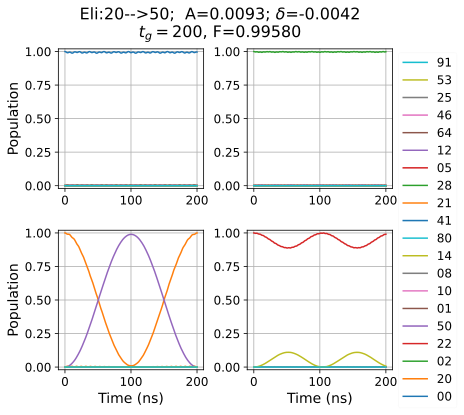

In [25]:
# The factor of 2pi converts the energy to GHz so that the time is in units of ns
options = qt.Options(nsteps=10000, store_states=True)
tg = 200
detune= -0.00424141 #-0.01716187
drive_amp= 0.00925934
tlist = np.linspace(0, tg, num=int(tg))  # total time
pulse_args = {'drive_amp': drive_amp,
                'drive_freq': detune + trans_freq,
                 'gate_time': tg
                 }

H_qbt_drive = [ diag_hamiltonian_trunc, [2* np.pi* N_b_trunc, ut.cos_pulse]  ]
result = {}
logi_state = [0,2]
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive,
            qt.basis(total_truncation, trunc_states.index(str(state_i) + str(state_j))),
            tlist,
            e_ops=e_ops,
            args=pulse_args,
            options=options  )

prop = qt.propagator(H_qbt_drive, tlist, args=pulse_args)[-1]  # get the propagator at the final time step
fidelity = ut.cz_fidelity(prop, state_logi=comp_subspace, state_tot=total_subspace)
print(fidelity)

#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,5.8), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle('Eli:'+state0+'-->'+state1 + ';  A=%.4f; '%drive_amp + '$\delta$=%.4f\n'%detune+
                '$t_g=$%d'%tg+', F=%.5f'%fidelity)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in enumerate(result[idx,jdx].expect):
            ax[idx][jdx].plot(tlist, res, label=r"%s" % trunc_states[kdx])
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
        # ax[idx][jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
        # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1],
                loc='center left',
                bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)
# plt.savefig('../image/zp_cz_full_simulate.png',dpi=150,bbox_inches='tight')

### 9. Get drive Hamiltonian, Solve master equation and Plot

0.009476741289909985


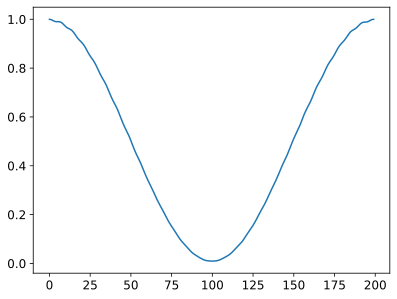

In [35]:
# np.shape(result[1,0].expect[trunc_states.index('22')])
pop = result[1,0].expect[trunc_states.index('20')]
# print(pop)
print(np.min(pop))
plt.plot(pop)

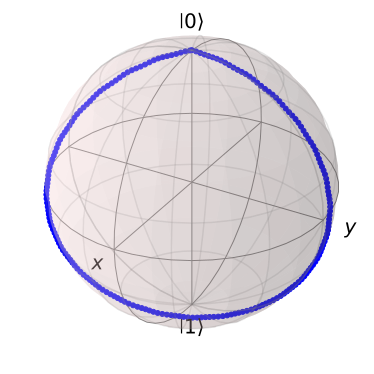

(0.7780735172470065, 0.7697483784816523)

In [11]:
# results = result[logi_state.index(int(state0[0])), logi_state.index(int(state0[1]))]
results = result[1,0]
i0 = trunc_states.index('20')
i1 = trunc_states.index('50')
diag_H = 2 * np.pi * qt.Qobj(np.diag([eval_tot[order_sort.index(state0)],
                                      eval_tot[order_sort.index(state1)]]))
psi_list = [(1.0j*tlist[x]*diag_H).expm()*qt.Qobj(results.states[x][[i0, i1]])
                    for x in range(len(results.states))][:]

xx = qt.expect(qt.sigmax(), psi_list)
yy = qt.expect(qt.sigmay(), psi_list)
zz = qt.expect(qt.sigmaz(), psi_list)

b = qt.Bloch()
b.add_points([xx, yy, zz])
b.show()

XX, YY = ut.labmert_proj(zz, yy, xx)
factor2 = 0.5*((4*np.pi-ut.PolyArea(XX, YY))/np.pi)
# factor2b = 0.5*((ut.PolyArea(XX, YY))/np.pi)
factor2, (ut.geometric_phase_integral(xx, yy, zz)/np.pi)%2

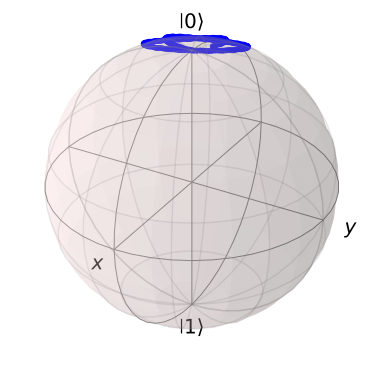

(1.908546181247334, 1.785190984869629)

In [12]:
results = result[1,1]
state_m = '22'
state_n = '53'
i0 = trunc_states.index(state_m)
i1 = trunc_states.index(state_n)
diag_H = 2 * np.pi * qt.Qobj(np.diag([eval_tot[order_sort.index(state_m)],
                                      eval_tot[order_sort.index(state_n)]]))
psi_list = [(1.0j*tlist[x]*diag_H).expm()*qt.Qobj(results.states[x][[i0, i1]])
                    for x in range(len(results.states))]

xx = qt.expect(qt.sigmax(), psi_list)
yy = qt.expect(qt.sigmay(), psi_list)
zz = qt.expect(qt.sigmaz(), psi_list)

b = qt.Bloch()
b.add_points([xx, yy, zz])
b.show()

XX, YY = ut.labmert_proj(zz, yy, xx)
factor2 = 0.5*((4*np.pi-ut.PolyArea(XX, YY))/np.pi)
factor2, (ut.geometric_phase_integral(xx, yy, zz)/np.pi)%2

# Solve master equation in rotating frame

0it [00:00, ?it/s]

10.0%. Run time:   5.07s. Est. time left: 00:00:00:45
20.0%. Run time:  10.15s. Est. time left: 00:00:00:40
30.0%. Run time:  15.23s. Est. time left: 00:00:00:35
40.0%. Run time:  20.32s. Est. time left: 00:00:00:30
50.0%. Run time:  25.41s. Est. time left: 00:00:00:25
60.0%. Run time:  30.54s. Est. time left: 00:00:00:20
70.0%. Run time:  35.62s. Est. time left: 00:00:00:15
80.0%. Run time:  40.71s. Est. time left: 00:00:00:10
90.0%. Run time:  45.75s. Est. time left: 00:00:00:05


1it [00:50, 50.56s/it]

Total run time:  50.56s
10.0%. Run time:   6.58s. Est. time left: 00:00:00:59
20.0%. Run time:  13.03s. Est. time left: 00:00:00:52
30.0%. Run time:  19.52s. Est. time left: 00:00:00:45
40.0%. Run time:  25.98s. Est. time left: 00:00:00:38
50.0%. Run time:  32.49s. Est. time left: 00:00:00:32
60.0%. Run time:  38.94s. Est. time left: 00:00:00:25
70.0%. Run time:  45.37s. Est. time left: 00:00:00:19
80.0%. Run time:  51.86s. Est. time left: 00:00:00:12
90.0%. Run time:  58.32s. Est. time left: 00:00:00:06


2it [01:55, 57.53s/it]


...

10.0%. Run time:   6.33s. Est. time left: 00:00:00:56
20.0%. Run time:  12.78s. Est. time left: 00:00:00:51
30.0%. Run time:  19.15s. Est. time left: 00:00:00:44
40.0%. Run time:  25.40s. Est. time left: 00:00:00:38
50.0%. Run time:  31.69s. Est. time left: 00:00:00:31
60.0%. Run time:  38.06s. Est. time left: 00:00:00:25
70.0%. Run time:  44.40s. Est. time left: 00:00:00:19
80.0%. Run time:  50.80s. Est. time left: 00:00:00:12
90.0%. Run time:  57.22s. Est. time left: 00:00:00:06


1it [01:03, 63.34s/it]

Total run time:  63.33s
10.0%. Run time:   9.06s. Est. time left: 00:00:01:21
20.0%. Run time:  18.12s. Est. time left: 00:00:01:12
30.0%. Run time:  27.28s. Est. time left: 00:00:01:03
40.0%. Run time:  36.46s. Est. time left: 00:00:00:54
50.0%. Run time:  45.65s. Est. time left: 00:00:00:45
60.0%. Run time:  54.74s. Est. time left: 00:00:00:36
70.0%. Run time:  63.95s. Est. time left: 00:00:00:27
80.0%. Run time:  73.10s. Est. time left: 00:00:00:18
90.0%. Run time:  82.24s. Est. time left: 00:00:00:09


2it [02:34, 77.11s/it]

Total run time:  90.89s


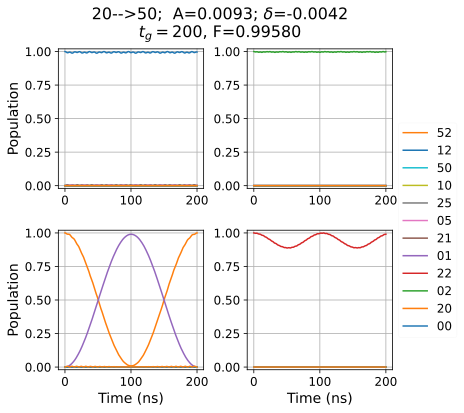

In [19]:
H1 = np.zeros(total_truncation)
for i, sta in enumerate(trunc_states):
    if sta in [state0, state1]:
        H1[i] = 2*np.pi*eval_tot[order_sort.index(sta)]
H1 = qt.Qobj(np.diag(H1))
H_0 = diag_hamiltonian_trunc - H1

def H_t(t, args):
    A = args.get('drive_amp', 0)
    wd = args.get('drive_freq', 0)
    tg = args.get('gate_time', 0)
    ft = A *  np.cos(wd * t) * (0<=t<=tg)
    H_time = ft * (1.0j*t*H1).expm() * 2*np.pi* N_b_trunc * (-1.0j*t*H1).expm()
    return H_0 + H_time

result = {}
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in tqdm(enumerate(logi_state)):
        result[idx, jdx] = qt.mesolve(
            H_t,
            qt.basis(total_truncation, trunc_states.index( str(state_i) + str(state_j) )),
            tlist,
            e_ops=e_ops,
            args=pulse_args,
            options=options,
            progress_bar=True  )

#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(6,5.8), nrows=2, ncols=2)
#ax[0].plot(tlist, drive)
fig.suptitle(state0+'-->'+state1 + ';  A=%.4f; '%drive_amp + '$\delta$=%.4f\n'%detune+
                '$t_g=$%d'%tg+', F=%.5f'%fidelity)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state):
    for jdx, state_j in enumerate(logi_state):
        for kdx, res in zip(idxs, result[idx,jdx].expect):
            ax[idx][jdx].plot(tlist, res, label=r"%s" % order_sort[kdx])
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
ax[1][1].legend(handles[::-1],labels[::-1],
                loc='center left',
                bbox_to_anchor=(1, 1)).get_frame().set_alpha(0.1)

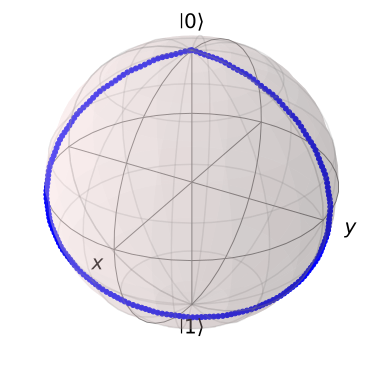

(0.7806287707626306, 0.7723843941179502)

In [21]:
i0 = trunc_states.index(state0)
i1 = trunc_states.index(state1)
results = result[logi_state.index(int(state0[0])), logi_state.index(int(state0[1]))]
psi_list = [qt.Qobj(results.states[x][[i0, i1]]) for x in range(len(results.states))]

xx = qt.expect(qt.sigmax(), psi_list)
yy = qt.expect(qt.sigmay(), psi_list)
zz = qt.expect(qt.sigmaz(), psi_list)

b = qt.Bloch()
b.add_points([xx, yy, zz])
b.show()

XX, YY = ut.labmert_proj(zz, yy, xx)
factor2 = 0.5*((4*np.pi-ut.PolyArea(XX, YY))/np.pi)
factor2, (ut.geometric_phase_integral(xx, yy, zz)/np.pi)%2

In [13]:
# w20 = trans_freq
# w22 = np.abs(ut.transition_frequency(order_sort.index('22') ,order_sort.index('52'), eval_tot))
# wd = detune + trans_freq
# print('w20-50=', w20)
# print('w22-52=', w22)
# print('w_drive=', wd)
# print('w20-w22, wd-w20:',w20-w22, wd-w20)

zz = ( eval_tot[order_sort.index('22')] + eval_tot[order_sort.index('00')]
        - eval_tot[order_sort.index('02')] - eval_tot[order_sort.index('20')] )
print('dynamical phase = ',zz * 2*np.pi *100)

dynamical phase =  -0.00016335248927569913


### 8. Get dressed index for logical states

In [14]:
###############################################
# convert the product states to the closes eigenstates of the dressed system
product_states = ['00', '20', '02', '22',
                  '01', '21', '05', '25',
                  '10', '50', '12', '52'  ]

idxs = [order_sort.index(i) for i in product_states]
print('state index: ', idxs)

state index:  [0, 5, 3, 21, 1, 12, 10, 40, 2, 14, 16, 44]


### 7. Calculate 8 important transition energies

In [15]:
start_list = ['00', '00', '02', '02', '20', '20', '22', '22']
end_list   = ['01', '10', '12', '05', '50', '21', '52', '25']
eff_num = 5  # number of effective digits in np.round()

state_list = []
dw_list = []
mat_list= []
for i,j in zip(start_list, end_list):
    state_list.append(i + '-' + j)
    dw_list.append(np.abs( ut.transition_frequency( order_sort.index(i) , order_sort.index(j), eval_tot )))
    mat_list.append(np.abs(n_theta2_dress_mat[order_sort.index(i) , order_sort.index(j)]))

dw_num = len(dw_list)
sort_idxs    = np.array(dw_list).argsort()
state_list  = np.array([state_list[idx] for idx in sort_idxs])
mat_list  = np.array([mat_list[idx] for idx in sort_idxs])
dw_list = np.round( np.sort(dw_list), eff_num )

[print(state_list[i],' : ', dw_list[i], ' : ', mat_list[i]) for i in range(dw_num)];

22-25  :  14.69007  :  1.239227276501971
02-05  :  14.71051  :  1.2577211490017246
20-21  :  15.10059  :  1.1977080684180206
00-01  :  15.14523  :  1.2521891297744943
22-52  :  15.86275  :  0.0
20-50  :  15.99727  :  0.5366976548340731
02-12  :  16.28165  :  0.269909734748197
00-10  :  16.31768  :  0.3931762228820889


In [16]:
levels_label2 = ["00","02","20","22","05","50","25","52","55"]
level_idx = [order_sort.index(levels_label2[i]) for i in range(len(levels_label2))]
n_theta2_dress_extract = np.zeros((len(levels_label2), len(levels_label2)), dtype=complex)
for idx, level_i in enumerate(level_idx):
    for jdx, level_j in enumerate(level_idx):
        n_theta2_dress_extract[idx, jdx] = n_theta2_dress_mat[level_i, level_j]
qt.Qobj(np.round(np.abs(n_theta2_dress_extract), 3))

Quantum object: dims = [[9], [9]], shape = (9, 9), type = oper, isherm = True
Qobj data =
[[0.000e+00 0.000e+00 0.000e+00 0.000e+00 7.000e-03 0.000e+00 0.000e+00
  0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.258e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 5.370e-01 7.000e-03
  0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 7.000e-03 1.239e+00
  0.000e+00 0.000e+00]
 [7.000e-03 1.258e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  1.500e-02 0.000e+00]
 [0.000e+00 0.000e+00 5.370e-01 7.000e-03 0.000e+00 0.000e+00 0.000e+00
  1.000e-03 0.000e+00]
 [0.000e+00 0.000e+00 7.000e-03 1.239e+00 0.000e+00 0.000e+00 0.000e+00
  1.000e-03 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.500e-02 1.000e-03 1.000e-03
  0.000e+00 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00]]

In [17]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

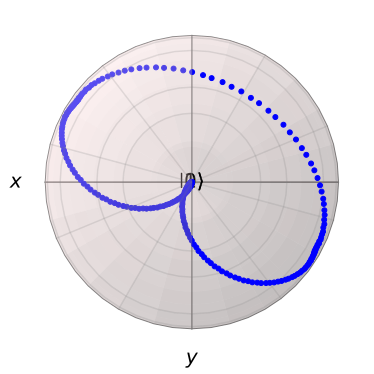

In [ ]:
b = qt.Bloch()
b.add_points([xx, yy, zz])
b.view=[0,90]
b.show()

In [ ]:
prop = qt.propagator(H_t, tlist, args=pulse_args, parallel=True,  progress_bar=True)[-1]  # get the propagator at the final time step
fidelity = ut.cz_fidelity(prop, computational_subspace, logi_states=states)
fidelity

11.1%. Run time:  51.43s. Est. time left: 00:00:06:51
20.0%. Run time:  53.59s. Est. time left: 00:00:03:34
31.1%. Run time:  54.54s. Est. time left: 00:00:02:00
40.0%. Run time:  54.85s. Est. time left: 00:00:01:22
51.1%. Run time:  57.44s. Est. time left: 00:00:00:54
60.0%. Run time:  57.46s. Est. time left: 00:00:00:38
71.1%. Run time:  57.47s. Est. time left: 00:00:00:23
80.0%. Run time:  57.48s. Est. time left: 00:00:00:14
91.1%. Run time:  57.49s. Est. time left: 00:00:00:05
100.0%. Run time:  57.51s. Est. time left: 00:00:00:00
Total run time:  57.71s


0.5439107592134171

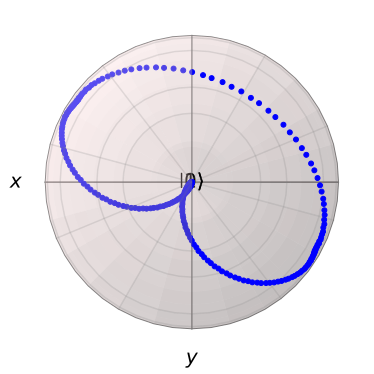

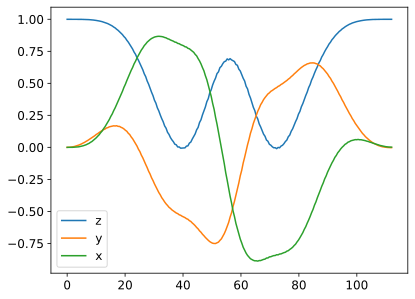

In [ ]:
Lzero = qt.basis(total_truncation, 5)
Lone = qt.basis(total_truncation, 14)

sz = Lzero*Lzero.dag() - Lone*Lone.dag()
sx = Lzero*Lone.dag() + Lone*Lzero.dag()
sy =1j*( -Lzero*Lone.dag() + Lone*Lzero.dag() )

blochs =  qt.expect([sx,sy,sz],result[1, 0].states)
b = qt.Bloch()
b.clear()
pnts = [blochs[0], blochs[1], blochs[2]]
b.add_points(pnts)
b.view=[0,90]
b.render()
b.show()

plt.plot(tlist, blochs[2],label='z')
plt.plot(tlist, blochs[1],label='y')
plt.plot(tlist, blochs[0], label='x')
plt.legend()